# 21 — Partial order on 4 canonical social categories

Final consolidated pipeline. Same Greek-polity filter, 25-bucket resource
collapse, and asymmetric MORE / flipped-LESS evidence as notebooks 19 and 20,
restricted to a curated set of **4 social categories**:

* `Citizens` — free male citizens of a Greek polity (default civic+sex)
* `Women` — women in general (citizen wives, foreign women, etc.)
* `Slaves` — slaves of either sex
* `Foreigners` — resident aliens, non-Greeks living in Greek polities

**Asymmetric flip (unchanged from nb 19).** Only the marked → default direction fires:

| Default in-group | Flipped-LESS receives evidence from |
|---|---|
| Men → routes to `Citizens` | Women, Wives, Minors, Elders, Sick |
| Citizens → routes to `Citizens` | Slaves, Foreigners, Exiles |
| Greeks → routes to `Citizens` | Macedonians, Scythians, Syrians |
| The wealthy → routes to `Citizens` | The poor / multitude |
| Heirs → routes to `Citizens` | Orphans |
| Women → `Women` | none — no flip toward marked groups |
| Slaves → `Slaves` | none |
| Foreigners → `Foreigners` | none |

Each rule (original MORE or flipped-MORE) is routed to one or more of the 4
canonical categories. Nobles, Magistrates, Kings, etc. all route to `Citizens`.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
from matplotlib.patches import Patch

DATA_PATH = Path('../data/rules_dataset_april_2026.tsv')

PERIOD_MAP = {
    'Classical (500–360 BCE)':                      'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)':                 'Late Classical (354–165 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Roman (165 BCE – 205 CE)',
    'High Roman Empire (135–205 CE)':               'Roman (165 BCE – 205 CE)',
}
PERIOD_ORDER = [
    'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)',
    'Roman (165 BCE – 205 CE)',
]

GREEK_POLITIES = {
    'Classical Athens', 'Hellenistic Athens', 'Archaic Athens',
    'Archaic Athens (Solonic)', 'Archaic Athens (Draconian)',
    'Archaic Athens (Peisistratid)', 'Archaic Athens (Pre-Solonic)',
    'Classical Athens (Solonic)', 'Classical Athens (Cleisthenic)',
    'Classical Athens (Eleusis)', 'Classical Athens (The Four Hundred)',
    'Classical Athens (The Five Thousand)', 'Classical Athens (the Five Thousand)',
    'Classical Sparta', 'Sparta', 'Archaic Sparta',
    'Classical Greece', 'Ancient Greece', 'Hellenistic Greece', 'Hellenistic Greek states',
    'Classical Thebes', 'Syracuse', 'Sicyon', 'Corinth', 'Aegina',
    'Mantineia', 'Mytilene', 'Oreus', 'Acragas', 'Delphi', 'Crete',
    'Chalcidice', 'Salamis (Cyprus)', 'Ionia and Pontus', 'Tarsus',
    'League of Corinth', 'Achaean League', 'Delphic Amphictyonic League',
    'Hellenistic Macedon', 'Macedonian Empire', 'Seleucid Empire',
    'Hierapolis (Syria)', 'Hellenistic Hierapolis',
    'Mythological / legendary setting',
}

GROUP_DROP   = {'Other'}
GROUP_RENAME = {'The poor': 'The poor / multitude', 'The multitude': 'The poor / multitude'}

RESOURCE_BUCKET = {
    'Right to own land':                          'Right to own property',
    'Right to retain own earnings':               'Right to retain property',
    'Right to dispose of property':               'Right to dispose / inherit property',
    'Right to inherit property':                  'Right to dispose / inherit property',
    'Right to inherit divine covenant':           'Right to dispose / inherit property',
    'Right to address the assembly':              'Right to public speech',
    'Right to speak first in assembly':           'Right to public speech',
    'Right to free speech':                       'Right to public speech',
    'Right to remuneration for office':           'Eligibility for public office',
    'Right to reside in the city':                'Right to reside / freedom of movement',
    'Right to freedom of movement':               'Right to reside / freedom of movement',
    'Right to a dowry':                           'Right to marriage / dowry',
    'Right to marry':                             'Right to marriage / dowry',
    'Right to professional judgement':            'Right to a legal trial',
    'Right to valid professional opinion':        'Right to a legal trial',
    'Right to military protection':               'Right to bear arms / military protection',
    'Right to bear arms':                         'Right to bear arms / military protection',
    'Protection from arbitrary banishment':       'Protection from banishment / prosecution',
    'Protection from legal prosecution':          'Protection from banishment / prosecution',
    'Protection from capital punishment':         'Protection from capital / corporal punishment',
    'Protection from corporal punishment':        'Protection from capital / corporal punishment',
    'Exemption from compulsory public financing': 'Exemption from taxes / public financing',
    'Exemption from public service financing':    'Exemption from taxes / public financing',
    'Exemption from taxes':                       'Exemption from taxes / public financing',
    'Exemption from manual labor':                'Exemption from compulsory service',
    'Exemption from military service':            'Exemption from compulsory service',
}

# --- Asymmetric flip: LESS-about-marked → MORE-about-default ---------------
OPPOSITE_GROUP = {
    'Women':                'Men',
    'Wives':                'Men',
    'Men':                  None,
    'Minors':               'Men',
    'Elders':               'Men',
    'Orphans':              'Heirs',
    'Heirs':                None,
    'Slaves':               'Citizens',
    'Foreigners':           'Citizens',
    'Exiles':               'Citizens',
    'Citizens':             None,
    'Macedonians':          'Greeks',
    'Scythians':            'Greeks',
    'Syrians':              'Greeks',
    'Greeks':               None,
    'Spartans':             None,
    'The poor / multitude': 'The wealthy',
    'The wealthy':          None,
    'Sick':                 'Men',
    'Physicians':           None,
    'Kings':                None,
    'Nobles':               None,
    'Magistrates':          None,
    'Artisans':             None,
    'Poets':                None,
    'Priests':              None,
    'Soldiers':             None,
    'Sailors':              None,
    'Philosophers':         None,
    'The educated':         None,
    'Christians':           None,
    'Jews':                 None,
    'Romans':               None,
}

# --- Routing: each group_meta atom → list of canonical categories ----------
CANONICAL_GROUPS = ['Citizens', 'Women', 'Slaves', 'Foreigners']

GROUP_TO_TARGETS = {
    # Civic groups
    'Citizens':              ['Citizens'],
    'Foreigners':            ['Foreigners'],
    'Slaves':                ['Slaves'],
    'Exiles':                ['Citizens'],
    # Sex
    'Men':                   ['Citizens'],
    'Women':                 ['Women'],
    'Wives':                 ['Women'],
    # Compound / office — all citizen-male
    'Nobles':                ['Citizens'],
    'Magistrates':           ['Citizens'],
    'Kings':                 ['Citizens'],
    'Heirs':                 ['Citizens'],
    'Spartans':              ['Citizens'],
    'Priests':               ['Citizens'],
    # Vocations
    'Soldiers':              ['Citizens'],
    'Sailors':               ['Citizens'],
    'Artisans':              ['Citizens'],
    'Physicians':            ['Citizens'],
    'Philosophers':          ['Citizens'],
    'Poets':                 ['Citizens'],
    'The educated':          ['Citizens'],
    # Wealth
    'The wealthy':           ['Citizens'],
    'The poor / multitude':  ['Citizens'],
    # Age
    'Minors':                ['Citizens'],
    'Orphans':               ['Citizens'],
    'Elders':                ['Citizens'],
    'Sick':                  ['Citizens'],
    # Ethnic
    'Greeks':                ['Citizens'],
    'Macedonians':           ['Foreigners'],
    'Scythians':             ['Foreigners'],
    'Syrians':               ['Foreigners'],
    # Religious — sex- and civic-ambiguous
    'Christians':            ['Citizens', 'Foreigners', 'Women'],
    'Jews':                  ['Citizens', 'Foreigners', 'Women'],
    # Drop
    'Romans':                [],
}

MIN_RULES_PER_CELL = 1
MIN_RIGHTS         = 2
OVERLAP_MIN        = 0.1

COLOR_MORE    = '#1f4e79'   # dark blue — positive evidence (MORE rules)
COLOR_FLIP    = '#c97c2e'   # orange    — inferred via asymmetric flip
COLOR_BOTH    = '#5a3a8a'   # purple    — both sources present
COLOR_EMPTY   = '#f2f2f2'   # near-white

## Routing table — please validate

Each original `group_meta` atom is routed (after the asymmetric LESS-flip) to one or more of the 5 canonical categories:

| Original group | Targets |
|---|---|
| Citizens | Citizens |
| Foreigners | Foreigners |
| Slaves | Slaves |
| Exiles | Citizens |
| Men | Citizens |
| Women, Wives | Women |
| Nobles | Nobles, Citizens |
| Magistrates, Kings, Heirs, Spartans, Priests | Citizens |
| Soldiers, Sailors, Artisans, Physicians, Philosophers, Poets, The educated | Citizens |
| The wealthy, The poor / multitude | Citizens |
| Minors, Orphans, Elders, Sick | Citizens |
| Greeks | Citizens |
| Macedonians, Scythians, Syrians | Foreigners |
| Christians, Jews | Citizens, Foreigners, Women |
| Romans | dropped |

Edit `GROUP_TO_TARGETS` in the config cell to refine. A rule routed to two targets duplicates the row — so a `Nobles` rule supports both `Nobles` *and* `Citizens`.

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep='\t')
df_raw.shape, df_raw['directionality'].value_counts().to_dict()

((1011, 34), {'MORE': 549, 'LESS': 462})

In [3]:
def atoms(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

base = (df_raw
          .dropna(subset=['period', 'group_meta', 'resource_meta', 'rule_polity', 'directionality'])
          .assign(period=lambda d: d['period'].map(PERIOD_MAP))
          .dropna(subset=['period']))
base = base[base['rule_polity'].isin(GREEK_POLITIES)]
base = base.assign(resource_bucket=base['resource_meta'].map(lambda r: RESOURCE_BUCKET.get(r, r)))
base = base.assign(group_cat=base['group_meta'].apply(atoms)).explode('group_cat')
base = base[~base['group_cat'].isin(GROUP_DROP)]
base = base.assign(group_cat=base['group_cat'].replace(GROUP_RENAME))
base.shape

(855, 36)

In [4]:
more_rows = base[base['directionality'] == 'MORE'][['period', 'group_cat', 'resource_bucket']]
less_rows = base[base['directionality'] == 'LESS'][['period', 'group_cat', 'resource_bucket']]

flipped = less_rows.assign(group_cat=less_rows['group_cat'].map(OPPOSITE_GROUP)).dropna(subset=['group_cat'])

def to_targets(frame):
    out = frame.assign(group=frame['group_cat'].map(lambda g: GROUP_TO_TARGETS.get(g, [])))
    out = out.explode('group').dropna(subset=['group'])
    return out[['period', 'group', 'resource_bucket']]

more_t    = to_targets(more_rows)
flipped_t = to_targets(flipped)

positive = pd.concat([more_t.assign(origin='MORE'),
                      flipped_t.assign(origin='flipped LESS')],
                     ignore_index=True)
positive.shape, positive['origin'].value_counts().to_dict()

((652, 4), {'MORE': 491, 'flipped LESS': 161})

In [5]:
groups           = [g for g in CANONICAL_GROUPS if g in set(positive['group'])]
resource_buckets = sorted(positive['resource_bucket'].unique())
len(groups), len(resource_buckets)

(4, 26)

In [6]:
print('Canonical groups:')
print(groups)
print()
print('Resource buckets:')
print(resource_buckets)

Canonical groups:
['Citizens', 'Women', 'Slaves', 'Foreigners']

Resource buckets:
['Access to public honors', 'Access to religious rites', 'Access to the gymnasium', 'Eligibility for public office', 'Exemption from compulsory service', 'Exemption from legal audit', 'Exemption from taxes / public financing', 'Political power', 'Protection from banishment / prosecution', 'Protection from capital / corporal punishment', 'Protection from enslavement', 'Protection from public libel', 'Right to a legal trial', 'Right to adopt', 'Right to bear arms / military protection', 'Right to bodily autonomy', 'Right to burial', 'Right to citizenship', 'Right to dispose / inherit property', 'Right to drink wine', 'Right to marriage / dowry', 'Right to own property', 'Right to public speech', 'Right to reside / freedom of movement', 'Right to retain property', 'Right to vote in the Ekklesia']


## Distribution per persona / resource bucket

In [7]:
group_counts    = positive['group'].value_counts()
resource_counts = positive['resource_bucket'].value_counts()
print(f'{len(group_counts)} canonical groups, {len(resource_counts)} resource buckets, {len(positive)} rows')
print()
print('Group counts:')
print(group_counts)
print()
print('Top resource buckets:')
print(resource_counts.head(10))

4 canonical groups, 26 resource buckets, 652 rows

Group counts:
group
Citizens      574
Women          35
Foreigners     26
Slaves         17
Name: count, dtype: int64

Top resource buckets:
resource_bucket
Eligibility for public office                    128
Right to a legal trial                            58
Political power                                   53
Protection from capital / corporal punishment     48
Right to retain property                          36
Right to citizenship                              33
Right to dispose / inherit property               31
Right to vote in the Ekklesia                     28
Right to public speech                            23
Access to public honors                           23
Name: count, dtype: int64


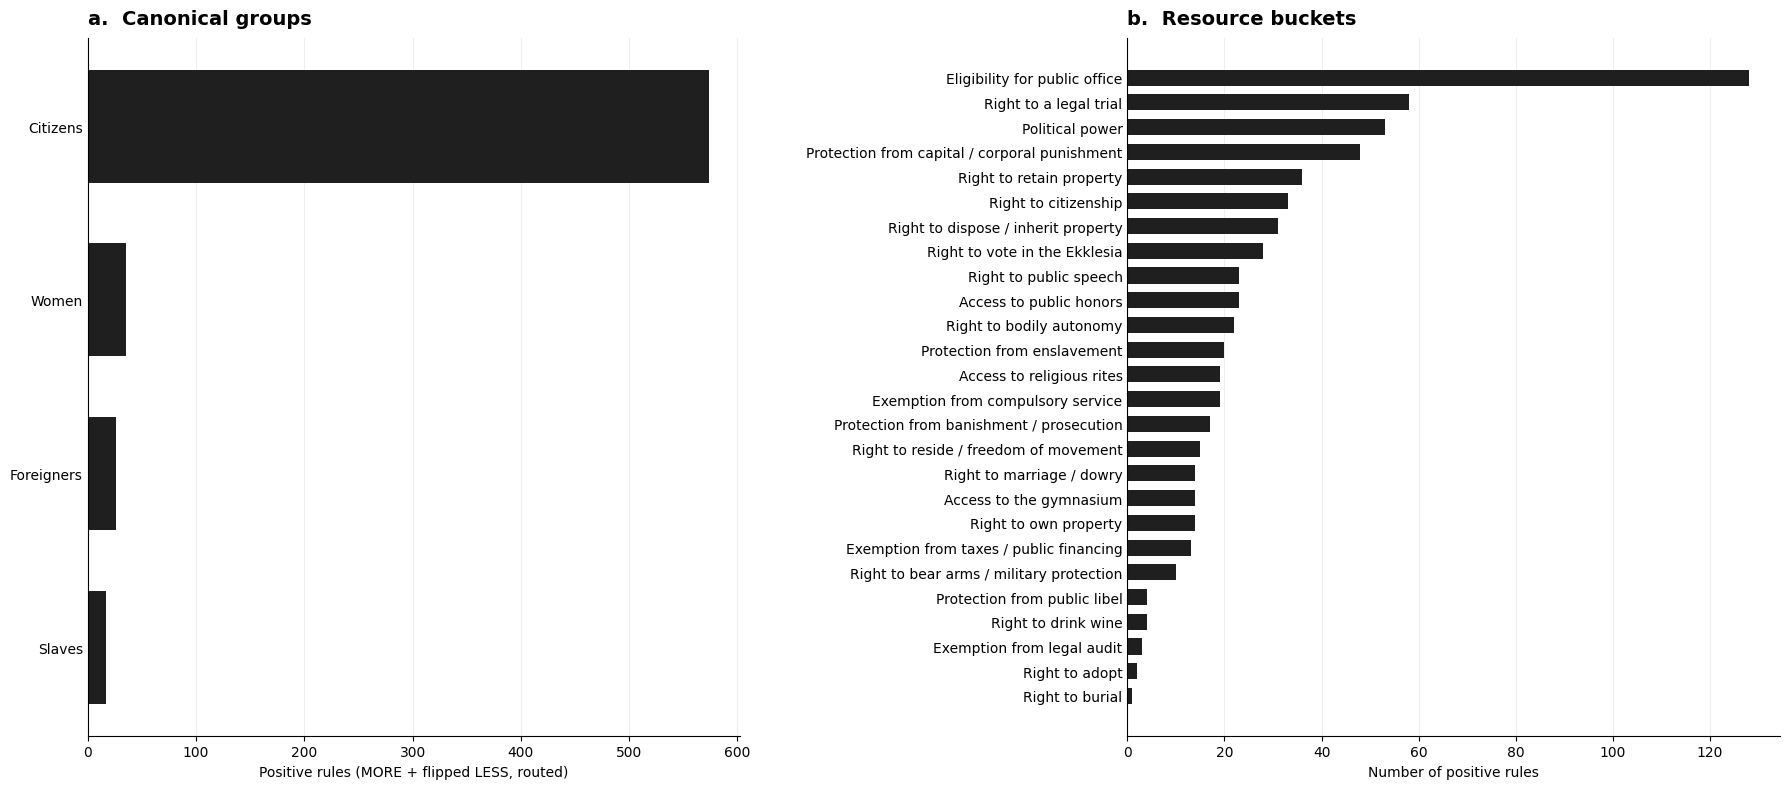

In [8]:
fig, (ax_p, ax_r) = plt.subplots(1, 2, figsize=(18, 8))
p = group_counts.sort_values()
ax_p.barh(p.index, p.values, color='#1f1f1f', height=0.65)
ax_p.set_xlabel('Positive rules (MORE + flipped LESS, routed)')
ax_p.set_title('a.  Canonical groups', fontsize=14, loc='left', pad=10, weight='semibold')
for s in ('top', 'right'): ax_p.spines[s].set_visible(False)
ax_p.tick_params(axis='y', length=0)
ax_p.grid(axis='x', color='#eeeeee', linewidth=0.8); ax_p.set_axisbelow(True)

r = resource_counts.sort_values()
ax_r.barh(r.index, r.values, color='#1f1f1f', height=0.65)
ax_r.set_xlabel('Number of positive rules')
ax_r.set_title('b.  Resource buckets', fontsize=14, loc='left', pad=10, weight='semibold')
for s in ('top', 'right'): ax_r.spines[s].set_visible(False)
ax_r.tick_params(axis='y', length=0)
ax_r.grid(axis='x', color='#eeeeee', linewidth=0.8); ax_r.set_axisbelow(True)
fig.tight_layout(w_pad=4)
plt.show()

In [9]:
cell_support = (positive
                  .groupby(['period', 'group', 'resource_bucket'])
                  .size()
                  .rename('n_rules')
                  .reset_index())
rights_long = pd.DataFrame(
    [(p, g, r) for p in PERIOD_ORDER for g in groups for r in resource_buckets],
    columns=['period', 'group', 'resource_bucket'],
).merge(cell_support, on=['period', 'group', 'resource_bucket'], how='left')
rights_long['n_rules']   = rights_long['n_rules'].fillna(0).astype(int)
rights_long['has_right'] = (rights_long['n_rules'] >= MIN_RULES_PER_CELL).astype(int)
rights_long.groupby('period')['has_right'].agg(['sum', 'count']).reindex(PERIOD_ORDER)

,sum,count
period,,
Classical (500–360 BCE),40,104
Late Classical (354–165 BCE),42,104
Roman (165 BCE – 205 CE),30,104


## Hasse diagram on personae

In [10]:
def right_sets(period):
    sub = rights_long[(rights_long['period'] == period) & (rights_long['has_right'] == 1)]
    sets = {g: frozenset(grp['resource_bucket']) for g, grp in sub.groupby('group')}
    return {g: s for g, s in sets.items() if len(s) >= MIN_RIGHTS}

{p: len(right_sets(p)) for p in PERIOD_ORDER}

{'Classical (500–360 BCE)': 4,
 'Late Classical (354–165 BCE)': 4,
 'Roman (165 BCE – 205 CE)': 4}

In [11]:
def approx_graph(sets, overlap_min=OVERLAP_MIN):
    classes = {}
    for g, s in sets.items():
        classes.setdefault(s, []).append(g)
    nodes = list(classes.keys())
    G = nx.DiGraph()
    for s in nodes:
        G.add_node(s, size=len(s))
    for a, b in combinations(nodes, 2):
        big, small = (b, a) if len(b) > len(a) else (a, b)
        if len(big) == len(small):
            continue
        if len(small & big) / len(small) >= overlap_min:
            G.add_edge(small, big)
    return nx.transitive_reduction(G), classes

def topological_positions(G):
    depth = {n: 0 for n in G.nodes}
    for n in reversed(list(nx.topological_sort(G))):
        for succ in G.successors(n):
            if depth[n] < depth[succ] + 1:
                depth[n] = depth[succ] + 1
    max_d = max(depth.values()) if depth else 0
    levels = {}
    for n in G.nodes:
        levels.setdefault(max_d - depth[n], []).append(n)
    pos = {}
    for y, nodes in levels.items():
        nodes = sorted(nodes, key=lambda s: sorted(s))
        for i, n in enumerate(nodes):
            pos[n] = ((i + 1) / (len(nodes) + 1), y)
    return pos

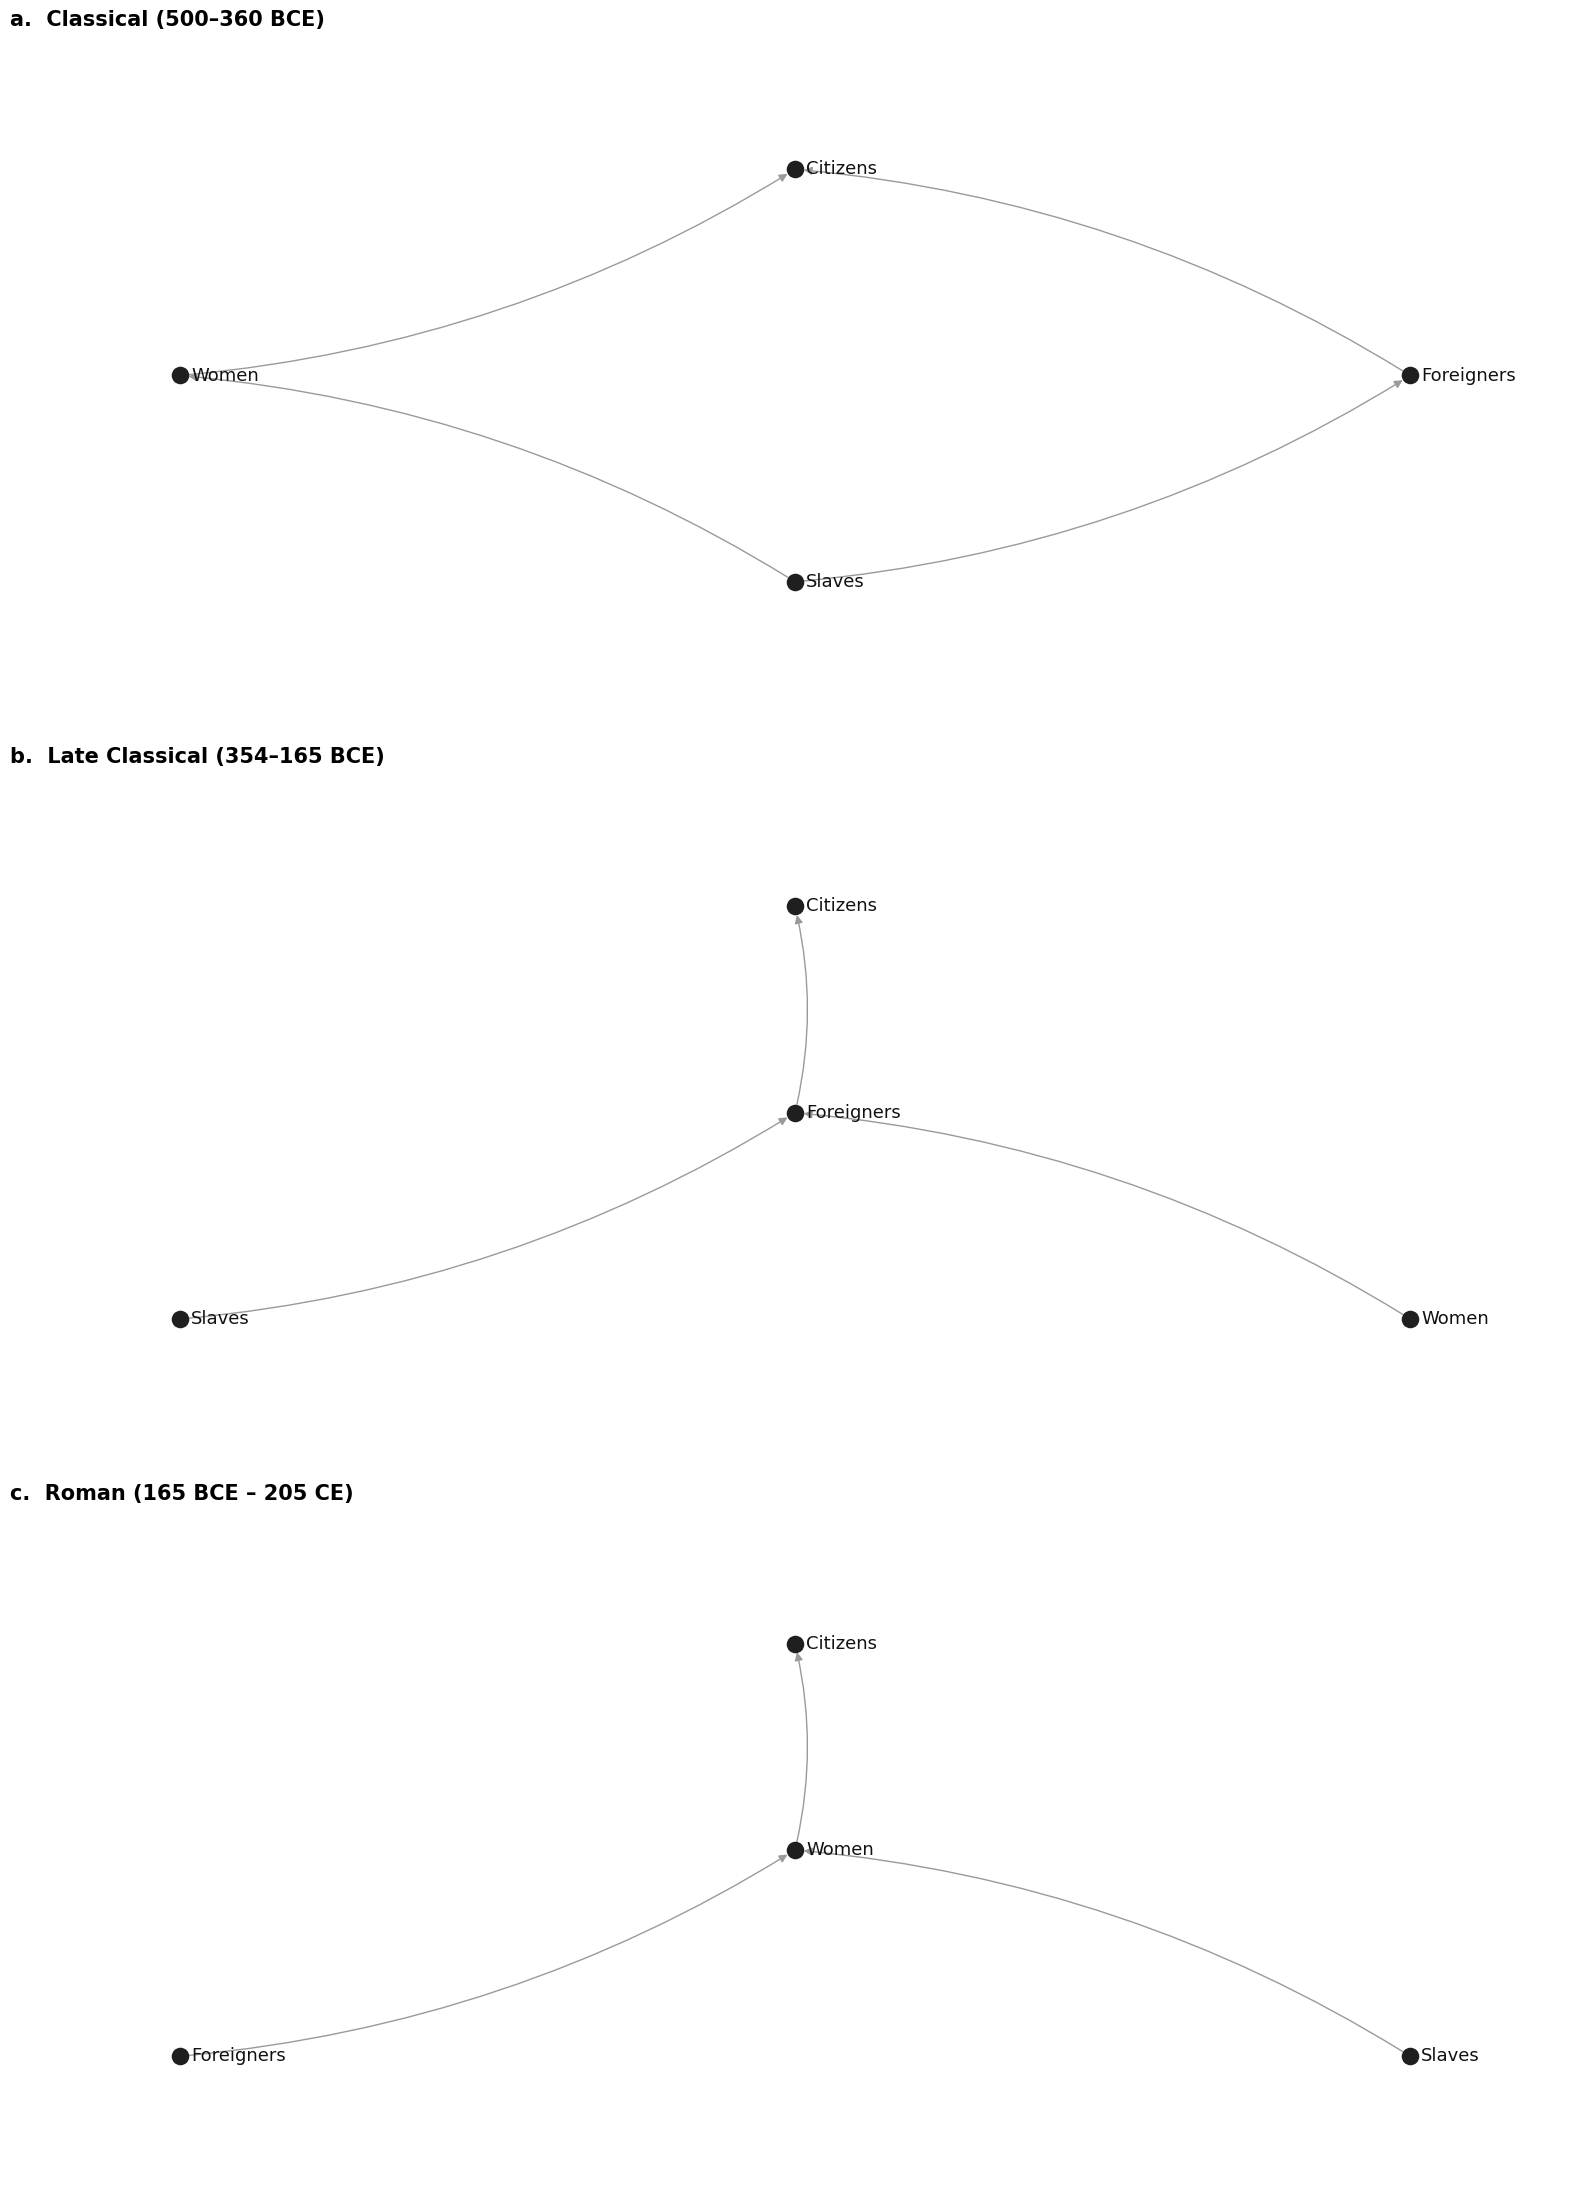

In [12]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  14,
    'axes.titlesize':  15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
})
NODE_SIZE = 160
fig, axes = plt.subplots(3, 1, figsize=(16, 22))

for letter, ax, period in zip('abc', axes, PERIOD_ORDER):
    sets = right_sets(period)
    G, classes = approx_graph(sets)
    pos = topological_positions(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=NODE_SIZE, node_color='#1f1f1f', linewidths=0)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#9a9a9a', width=1.0,
                            arrows=True, arrowstyle='-|>', arrowsize=12,
                            node_size=NODE_SIZE, connectionstyle='arc3,rad=0.12',
                            min_source_margin=4, min_target_margin=4)
    for n, (x, y) in pos.items():
        ax.annotate(', '.join(classes[n]), xy=(x, y), xytext=(8, 0),
                    textcoords='offset points', ha='left', va='center',
                    fontsize=13, color='#111111')
    ymax = max(y for _, y in pos.values()) if pos else 0
    ax.set_title(f'{letter}.  {period}', fontsize=15, loc='left', pad=14, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(axis='both', length=0)
    ax.set_ylim(-0.6, ymax + 0.6); ax.margins(x=0.08)
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

fig.tight_layout(h_pad=3)
plt.show()

## Rights per group per period

In [13]:
for period in PERIOD_ORDER:
    sets = right_sets(period)
    print(f'=== {period} ===')
    for g in CANONICAL_GROUPS:
        if g in sets:
            rights = sorted(sets[g])
            body = ', '.join(rights)
            print(f'{g} ({len(rights)}) = {{ {body} }}')
        else:
            print(f'{g} (—) = {{ }}    # below MIN_RIGHTS={MIN_RIGHTS}')
    print()

=== Classical (500–360 BCE) ===
Citizens (20) = { Access to public honors, Access to religious rites, Access to the gymnasium, Eligibility for public office, Exemption from compulsory service, Political power, Protection from banishment / prosecution, Protection from capital / corporal punishment, Protection from enslavement, Protection from public libel, Right to a legal trial, Right to adopt, Right to bodily autonomy, Right to citizenship, Right to dispose / inherit property, Right to own property, Right to public speech, Right to reside / freedom of movement, Right to retain property, Right to vote in the Ekklesia }
Women (7) = { Access to religious rites, Right to bodily autonomy, Right to dispose / inherit property, Right to marriage / dowry, Right to own property, Right to public speech, Right to retain property }
Slaves (6) = { Protection from banishment / prosecution, Protection from capital / corporal punishment, Right to a legal trial, Right to citizenship, Right to public sp

## Rights by origin — positive (MORE) vs inferred (flipped LESS)

Three panels (one per period). Rows are resource buckets, columns are the four canonical groups. Each cell is coloured by where the evidence comes from:

* **Blue** — at least one positive `MORE` rule
* **Orange** — only inferred via the asymmetric `LESS → MORE` flip
* **Purple** — both positive *and* inferred evidence
* **Empty** — no evidence in this period

The two numbers in each cell are `+M  /  +F` — count of MORE rules and count of flipped-LESS rules feeding that (group, right, period) cell.

In [14]:
origin_counts = (positive
                 .groupby(['period', 'group', 'resource_bucket', 'origin'])
                 .size()
                 .unstack('origin', fill_value=0)
                 .reset_index())
for col in ('MORE', 'flipped LESS'):
    if col not in origin_counts.columns:
        origin_counts[col] = 0
origin_counts.head()

origin,period,group,resource_bucket,MORE,flipped LESS
0,Classical (500–360 BCE),Citizens,Access to public honors,4,0
1,Classical (500–360 BCE),Citizens,Access to religious rites,7,0
2,Classical (500–360 BCE),Citizens,Access to the gymnasium,3,1
3,Classical (500–360 BCE),Citizens,Eligibility for public office,25,2
4,Classical (500–360 BCE),Citizens,Exemption from compulsory service,7,1


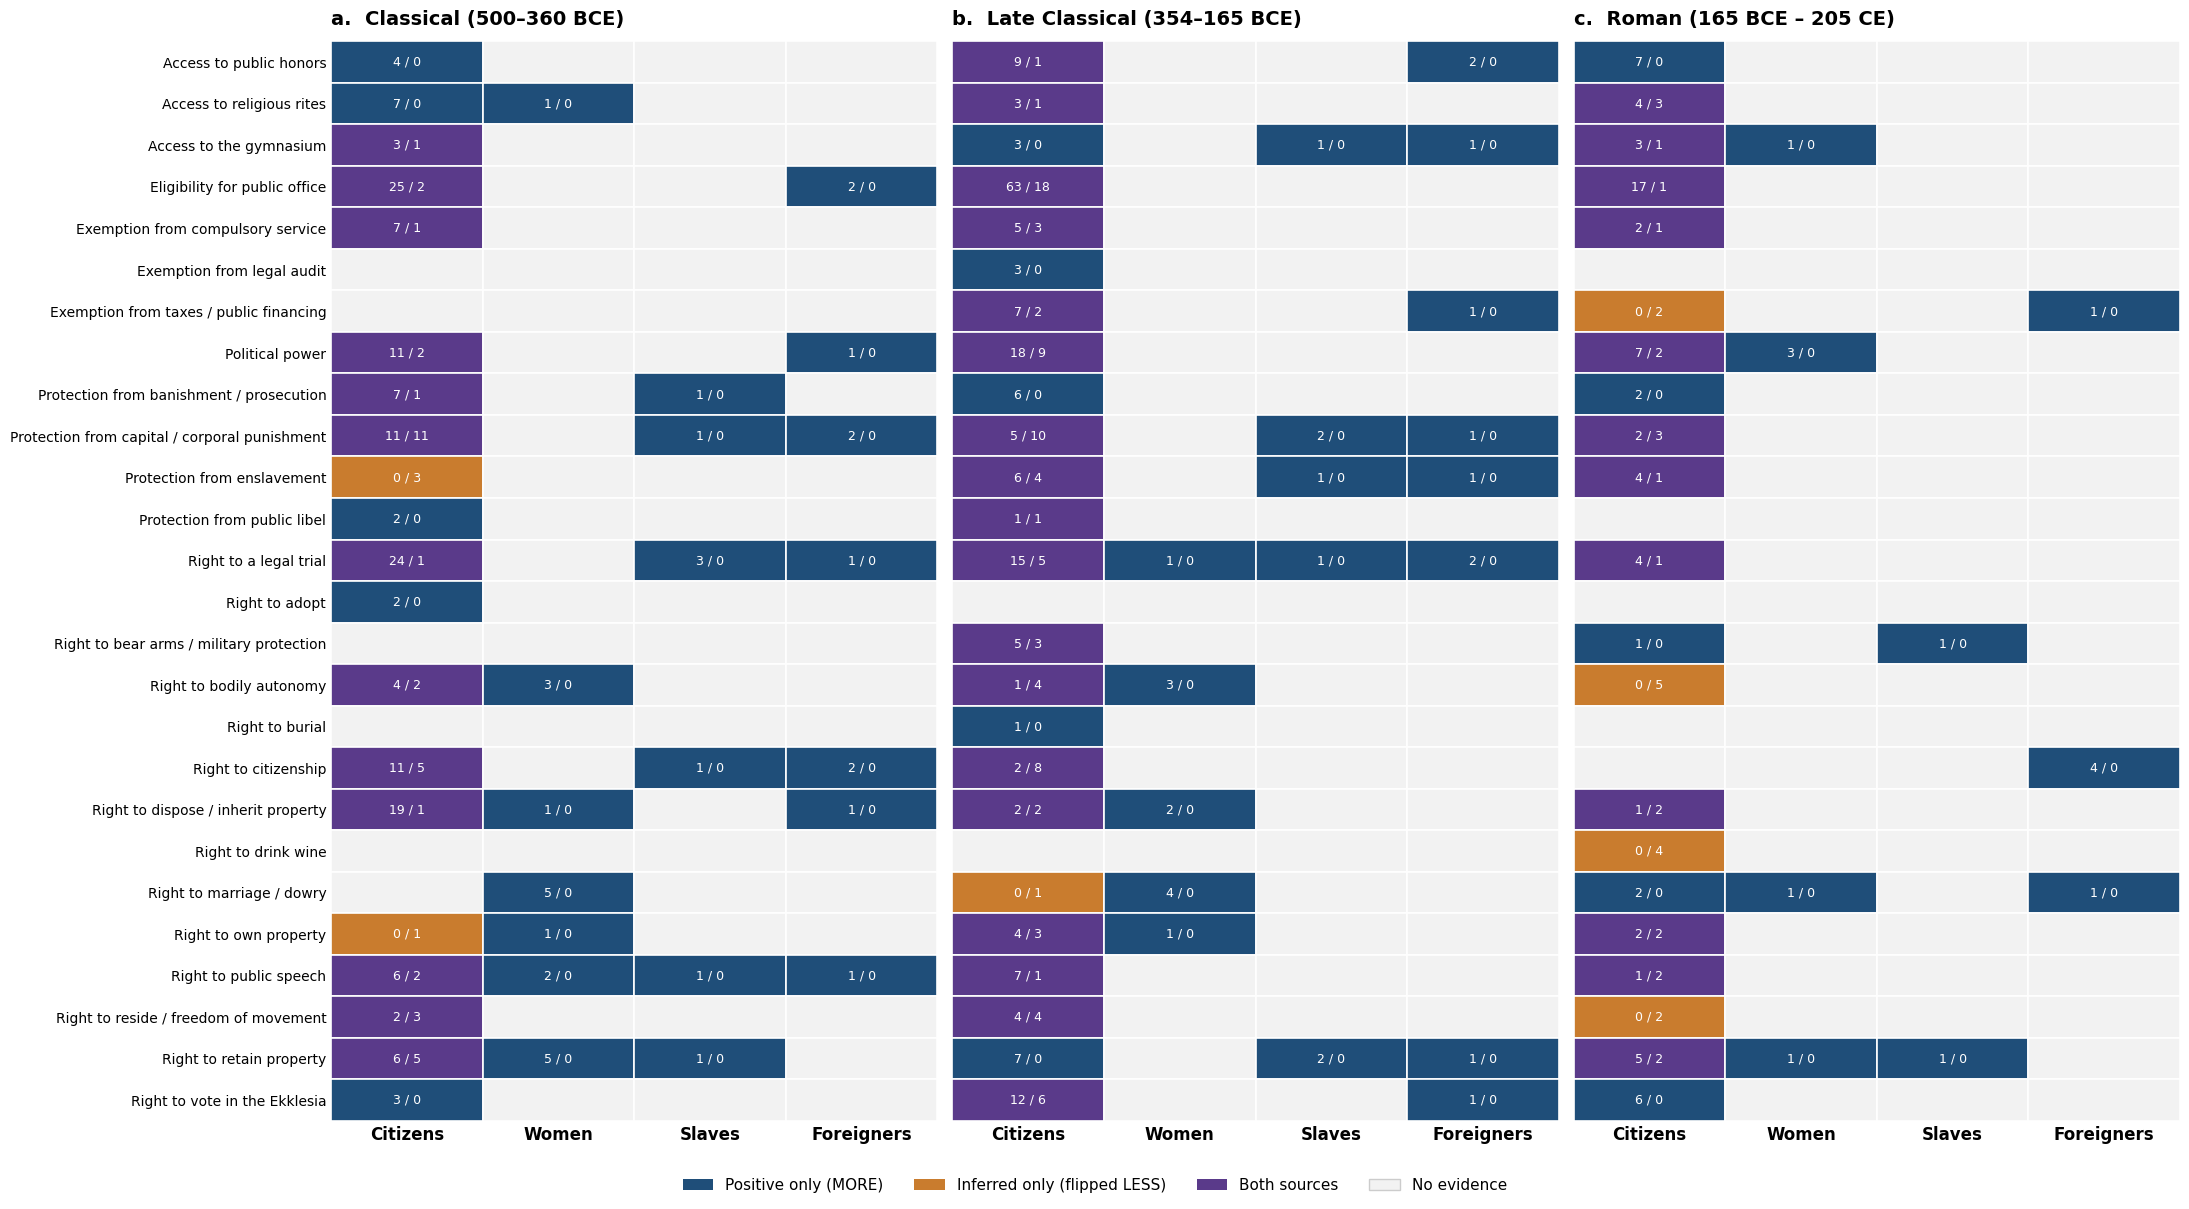

In [15]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 11,
})

groups_x = CANONICAL_GROUPS
rights_y = sorted(positive['resource_bucket'].unique())

def cell_color(m, f):
    if m > 0 and f > 0: return COLOR_BOTH
    if m > 0:           return COLOR_MORE
    if f > 0:           return COLOR_FLIP
    return COLOR_EMPTY

fig, axes = plt.subplots(1, 3, figsize=(22, 12))

for letter, ax, period in zip('abc', axes, PERIOD_ORDER):
    sub = origin_counts[origin_counts['period'] == period]
    n_rows, n_cols = len(rights_y), len(groups_x)
    M = np.zeros((n_rows, n_cols), dtype=int)
    F = np.zeros((n_rows, n_cols), dtype=int)
    for _, r in sub.iterrows():
        if r['group'] not in groups_x or r['resource_bucket'] not in rights_y:
            continue
        i = rights_y.index(r['resource_bucket'])
        j = groups_x.index(r['group'])
        M[i, j] = int(r.get('MORE', 0))
        F[i, j] = int(r.get('flipped LESS', 0))

    for i in range(n_rows):
        for j in range(n_cols):
            color = cell_color(M[i, j], F[i, j])
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor=color, edgecolor='white', linewidth=1.2))
            if M[i, j] or F[i, j]:
                txt_color = '#ffffff' if color != COLOR_EMPTY else '#111111'
                ax.text(j, i, f'{M[i,j]} / {F[i,j]}',
                        ha='center', va='center', fontsize=9, color=txt_color)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(groups_x, rotation=0, fontsize=12, weight='semibold')
    ax.set_yticks(range(n_rows))
    if letter == 'a':
        ax.set_yticklabels(rights_y, fontsize=10)
    else:
        ax.set_yticklabels([''] * n_rows)
    ax.tick_params(axis='both', length=0)
    ax.set_title(f'{letter}.  {period}', fontsize=14, loc='left', pad=12, weight='semibold')
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

legend_handles = [
    Patch(facecolor=COLOR_MORE,  label='Positive only (MORE)'),
    Patch(facecolor=COLOR_FLIP,  label='Inferred only (flipped LESS)'),
    Patch(facecolor=COLOR_BOTH,  label='Both sources'),
    Patch(facecolor=COLOR_EMPTY, edgecolor='#cccccc', label='No evidence'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()